# 📘 Project 08 — Software Reliability Prediction
**Team No.:** 29  **Team Members:** Subhasmita Sahoo; Lipimudra Ray; Sibalika Behera

**Proposed Hybrid Model:** TabTransformer + Feature-Similarity Graph Attention Network (GAT)

**Dataset / Source:** NASA/PROMISE software defect datasets (CM1, KC1, KC2, KC3, MC1, MC2, MW1, PC1-PC4)  
**Dataset Link:** https://www.kaggle.com/datasets/yasserhessein/software-defects

**Task Type:** Binary classification — module defect proneness

---
## Data-Model Compatibility Note
The dataset contains per-module static-code metrics (McCabe/Halstead metrics) and a binary defect
label. It does **not** contain a real software call/dependency graph. Therefore, this notebook uses
a clearly documented **feature-similarity graph**: each module is connected to its nearest training
modules in the standardized metric space. The graph branch now performs actual attention-weighted
neighbor aggregation rather than only averaging neighbors.

To reduce leakage, identical metric fingerprints are kept in the same data partition and training
nodes are never allowed to use themselves as k-NN neighbors.

**Verdict: PARTIAL** — the TabTransformer branch uses the tabular metrics directly; the GAT branch
uses a similarity graph as a documented substitute for unavailable call-graph data.

**How to run:** `Runtime -> Run all` in Google Colab. Upload `kaggle.json` when prompted in Section 1.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm tabulate


In [2]:
import os
import sys
import json
import random
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve,
    matthews_corrcoef, mean_absolute_error, mean_squared_error, r2_score
)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."

DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device selected:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:
CONFIG = {
    "project_no": "08",
    "project_name": "Software_Reliability_Prediction",
    "team_no": "29",
    "task_type": "classification",
    "modality": "tabular",
    "kaggle_dataset_slug": "yasserhessein/software-defects",
    "dataset_source": "NASA/PROMISE software defect metrics",
    "target_column": "defects",
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "transformer_embed_dim": 32,
    "transformer_heads": 4,
    "gat_hidden_dim": 32,
    "knn_k": 8,
    "batch_size": 32,
    "epochs": 40,
    "learning_rate": 1e-3,
    "early_stop_patience": 6,
    "data_raw_dir": "data/08/raw",
    "data_processed_dir": "data/08/processed",
    "figures_dir": "data/08/figures",
    "results_dir": "data/08/results",
    "reports_dir": "data/08/reports",
}
for d in [CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
          CONFIG["results_dir"], CONFIG["reports_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG


{'project_no': '08',
 'project_name': 'Software_Reliability_Prediction',
 'team_no': '29',
 'task_type': 'classification',
 'modality': 'tabular',
 'kaggle_dataset_slug': 'yasserhessein/software-defects',
 'dataset_source': 'NASA/PROMISE software defect metrics',
 'target_column': 'defects',
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'transformer_embed_dim': 32,
 'transformer_heads': 4,
 'gat_hidden_dim': 32,
 'knn_k': 8,
 'batch_size': 32,
 'epochs': 40,
 'learning_rate': 0.001,
 'early_stop_patience': 6,
 'data_raw_dir': 'data/08/raw',
 'data_processed_dir': 'data/08/processed',
 'figures_dir': 'data/08/figures',
 'results_dir': 'data/08/results',
 'reports_dir': 'data/08/reports'}

## 1. Dataset Download

In [4]:
# Non-interactive first: kagglehub (anonymous download) avoids indefinitely blocking
# on files.upload() when run unattended. Only fall back to interactive kaggle.json
# upload if kagglehub is unavailable/fails.
import shutil
from pathlib import Path
downloaded = False
try:
    import kagglehub
    cache_path = kagglehub.dataset_download(CONFIG["kaggle_dataset_slug"])
    for item in Path(cache_path).rglob("*"):
        if item.is_file():
            dst = Path(CONFIG["data_raw_dir"]) / item.relative_to(cache_path)
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(item, dst)
    downloaded = True
    print("Downloaded via kagglehub.")
except Exception as exc:
    print(f"kagglehub failed ({exc}); falling back to interactive kaggle.json upload.")

if not downloaded:
    from google.colab import files
    if not os.path.exists("/root/.kaggle/kaggle.json"):
        print("Upload your kaggle.json:")
        uploaded = files.upload()
        os.makedirs("/root/.kaggle", exist_ok=True)
        for fname in uploaded:
            if fname.endswith(".json"):
                os.replace(fname, "/root/.kaggle/kaggle.json")
        os.chmod("/root/.kaggle/kaggle.json", 0o600)

    get_ipython().system('kaggle datasets download -d {CONFIG["kaggle_dataset_slug"]} -p {CONFIG["data_raw_dir"]} --unzip')


  0%|          | 0.00/380k [00:00<?, ?B/s]

100%|██████████| 380k/380k [00:00<00:00, 526kB/s]

100%|██████████| 380k/380k [00:00<00:00, 525kB/s]

Extracting files...


Downloaded via kagglehub.


In [5]:
raw_files = []
for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))
print(f"{len(raw_files)} files found")
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."
for f in raw_files[:20]:
    print(f, "-", os.path.getsize(f), "bytes")


11 files found
data/08/raw/Dataset/KC2.arff - 56191 bytes
data/08/raw/Dataset/PC2.arff - 92117 bytes
data/08/raw/Dataset/MW1.arff - 34030 bytes
data/08/raw/Dataset/KC1.arff - 169885 bytes
data/08/raw/Dataset/PC1.arff - 107366 bytes
data/08/raw/Dataset/PC4.arff - 185830 bytes
data/08/raw/Dataset/MC1.arff - 239485 bytes
data/08/raw/Dataset/KC3.arff - 28205 bytes
data/08/raw/Dataset/MC2.arff - 18905 bytes
data/08/raw/Dataset/CM1.arff - 57607 bytes
data/08/raw/Dataset/PC3.arff - 143001 bytes


## 2. Load Raw Data

In [6]:
# Load all CSV/ARFF project tables and tag every row with its source project.
def read_any_table(path):
    if path.lower().endswith(".csv"):
        d = pd.read_csv(path)
    elif path.lower().endswith(".arff"):
        from scipy.io import arff
        data, _ = arff.loadarff(path)
        d = pd.DataFrame(data)
        for c in d.select_dtypes(include=["object"]).columns:
            d[c] = d[c].map(
                lambda x: x.decode("utf-8", errors="ignore")
                if isinstance(x, (bytes, bytearray)) else x
            )
    else:
        return None

    d.columns = [str(c).strip() for c in d.columns]
    return d

tables = []
for f in raw_files:
    t = read_any_table(f)
    if t is not None and t.shape[1] > 3:
        t["_source_project"] = os.path.splitext(os.path.basename(f))[0]
        tables.append(t)

print(f"Loaded {len(tables)} tables")
assert len(tables) > 0, "No usable CSV/ARFF tables found"

df = pd.concat(tables, ignore_index=True, sort=False)
print("Combined shape:", df.shape)
df.head()


Loaded 11 tables
Combined shape: (10078, 74)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,V,L,D,I,E,B,T,c,GLOBAL_DATA_COMPLEXITY,GLOBAL_DATA_DENSITY
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,415.0,59.0,50.0,51.0,1159.0,8411.31,0.01,103.53,81.24,870848.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,230.0,33.0,10.0,16.0,575.0,3732.82,0.03,39.82,93.74,148644.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,175.0,26.0,12.0,13.0,500.0,3123.96,0.03,29.48,105.96,92103.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

In [7]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

LABEL_NAMES = {"defects", "defective", "problems", "class", "bug", "label"}
label_candidates = [c for c in df.columns if str(c).strip().lower() in LABEL_NAMES]
assert label_candidates, f"Could not find a defect-label column among: {list(df.columns)}"

# Prefer the candidate populated for the greatest number of rows.
LABEL_COL = max(label_candidates, key=lambda c: int(df[c].notna().sum()))
print("Label candidates:", label_candidates)
print("Selected label column:", LABEL_COL)
print("Selected-label non-null rows:", int(df[LABEL_COL].notna().sum()), "/", len(df))
print("Example label values:", df[LABEL_COL].dropna().unique()[:10])
print(df["_source_project"].value_counts())


Shape: (10078, 74)
Duplicate rows: 1369
Label candidates: ['class', 'Defective']
Selected label column: Defective
Selected-label non-null rows: 4382 / 10078
Example label values: ['N' 'Y']
_source_project
KC1    2109
MC1    1988
PC4    1458
PC1    1109
PC3    1077
PC2     745
KC2     522
CM1     498
MW1     253
KC3     194
MC2     125
Name: count, dtype: int64


In [8]:
def to_binary_defect(v):
    if pd.isna(v):
        return np.nan

    s = str(v).strip().lower()
    if s in {"true", "yes", "y", "1", "b'true'", "defective", "buggy"}:
        return 1
    if s in {"false", "no", "n", "0", "b'false'", "clean", "non-defective", "nondefective"}:
        return 0

    try:
        return int(float(s) > 0)
    except (ValueError, TypeError):
        return np.nan

target = CONFIG["target_column"]
converted_target = df[LABEL_COL].map(to_binary_defect)
unknown_count = int(df[LABEL_COL].notna().sum() - converted_target.notna().sum())
if unknown_count:
    print(f"Warning: {unknown_count} non-null label values could not be converted and will be dropped.")

df[target] = converted_target
df = df.dropna(subset=[target]).copy()
df[target] = df[target].astype(np.int64)

assert df[target].nunique() > 1, f"DEGENERATE TARGET: only {df[target].nunique()} unique value(s) found - {df[target].value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."

print("Rows after target cleaning:", len(df))
print(df[target].value_counts())
print(df[target].value_counts(normalize=True))

minority_frac = df[target].value_counts(normalize=True).min()
if minority_frac < 0.01 or len(df) < 100:
    print(f"[DATA QUALITY WARNING] rows={len(df)}, minority class fraction={minority_frac:.4f} - check upstream filtering/sampling.")


Rows after target cleaning: 4382
defects
0    4079
1     303
Name: count, dtype: int64
defects
0    0.930853
1    0.069147
Name: proportion, dtype: float64


**Data quality memo**

In [9]:
missing = df.isnull().mean().sort_values(ascending=False)
data_quality_memo = f"""# Data Quality Memo - Project 08: Software Reliability Prediction

## Dataset
- Source: NASA/PROMISE defect metrics ({len(tables)} project files concatenated: {sorted(df['_source_project'].unique())})
- Rows after target cleaning: {len(df)}
- Raw exact duplicate rows observed before modeling: {df.duplicated().sum()}

## Target
- Selected raw label column: {LABEL_COL}
- Defect rate: {df[target].mean():.4f}

## Missingness
{missing[missing > 0].to_string() if (missing > 0).any() else "No missing values."}

## Leakage controls
- All possible label-like columns are excluded from model inputs.
- `_source_project` is metadata only and is never supplied to the model.
- Identical numeric-metric fingerprints are kept in the same split.
- Validation/test graph neighbors are drawn only from training data.
- Training graph neighborhoods explicitly remove the node itself.

## Adaptation note
The original data contain no software call/dependency graph. The graph branch therefore uses a
k-NN feature-similarity graph over standardized static-code metrics. This is a proxy graph and
must not be described as a real call graph.
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w") as f:
    f.write(data_quality_memo)
print(data_quality_memo)


# Data Quality Memo - Project 08: Software Reliability Prediction

## Dataset
- Source: NASA/PROMISE defect metrics (11 project files concatenated: ['KC3', 'MC1', 'MC2', 'MW1', 'PC2', 'PC3'])
- Rows after target cleaning: 4382
- Raw exact duplicate rows observed before modeling: 0

## Target
- Selected raw label column: Defective
- Defect rate: 0.0691

## Missingness
loc                       1.000000
v(g)                      1.000000
ev(g)                     1.000000
iv(g)                     1.000000
n                         1.000000
v                         1.000000
l                         1.000000
d                         1.000000
i                         1.000000
e                         1.000000
b                         1.000000
t                         1.000000
lOCode                    1.000000
lOComment                 1.000000
lOBlank                   1.000000
lOCodeAndComment          1.000000
uniq_Op                   1.000000
uniq_Opnd                 1.000000


## 4. Preprocessing & Feature Engineering

In [10]:
# Exclude every label-like column, not only the selected one, to prevent target leakage.
excluded_cols = set(label_candidates) | {target, "_source_project"}

numeric_cols = [
    c for c in df.columns
    if c not in excluded_cols and pd.api.types.is_numeric_dtype(df[c])
]
numeric_cols = [c for c in numeric_cols if df[c].nunique(dropna=True) > 1]

assert numeric_cols, "No usable numeric metric columns were found."

feature_df = df[numeric_cols + [target, "_source_project"]].copy()

# Hash only the model metrics. Identical metric vectors are treated as one split-group so that
# duplicates/near-duplicate records with exactly the same inputs cannot leak across partitions.
feature_df["_metric_group"] = pd.util.hash_pandas_object(
    feature_df[numeric_cols], index=False
).astype("uint64")

print("Numeric metric columns used:", len(numeric_cols))
print(numeric_cols[:20])
print("Unique metric fingerprints:", feature_df["_metric_group"].nunique(), "/", len(feature_df))


Numeric metric columns used: 39
['BRANCH_COUNT', 'CALL_PAIRS', 'LOC_CODE_AND_COMMENT', 'LOC_COMMENTS', 'CONDITION_COUNT', 'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY', 'DESIGN_COMPLEXITY', 'DESIGN_DENSITY', 'EDGE_COUNT', 'ESSENTIAL_COMPLEXITY', 'ESSENTIAL_DENSITY', 'LOC_EXECUTABLE', 'PARAMETER_COUNT', 'HALSTEAD_CONTENT', 'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_ERROR_EST']
Unique metric fingerprints: 4382 / 4382


## 5. Train / Validation / Test Split

In [11]:
ratios = CONFIG["split_ratios"]
assert abs(sum(ratios.values()) - 1.0) < 1e-9, "Split ratios must sum to 1."

def grouped_holdout(data, test_size, seed, trials=250):
    """
    GroupShuffleSplit with repeated seeds. The best candidate is chosen to approximately preserve
    both requested size and global class balance while keeping metric fingerprints intact.
    """
    overall_rate = float(data[target].mean())
    best = None

    for trial in range(trials):
        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=seed + trial,
        )
        left_idx, right_idx = next(
            splitter.split(data, y=data[target], groups=data["_metric_group"])
        )
        left = data.iloc[left_idx]
        right = data.iloc[right_idx]

        # Penalize size mismatch and class-rate mismatch.
        size_error = abs(len(right) / len(data) - test_size)
        rate_error = abs(float(right[target].mean()) - overall_rate)
        score = size_error + 5.0 * rate_error

        # Both partitions must retain both classes.
        valid = left[target].nunique() == 2 and right[target].nunique() == 2
        if valid and (best is None or score < best[0]):
            best = (score, left.copy(), right.copy())

    if best is None:
        raise RuntimeError("Could not create a grouped split containing both classes.")
    return best[1], best[2]

# 70% train, 30% temporary holdout.
holdout_ratio = ratios["val"] + ratios["test"]
train_df, rest_df = grouped_holdout(feature_df, holdout_ratio, SEED)

# Split the temporary holdout into validation and test.
test_fraction_of_rest = ratios["test"] / holdout_ratio
val_df, test_df = grouped_holdout(rest_df, test_fraction_of_rest, SEED + 10_000)

# Verify no metric fingerprint occurs across partitions.
train_groups = set(train_df["_metric_group"])
val_groups = set(val_df["_metric_group"])
test_groups = set(test_df["_metric_group"])
assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))
print("Class rates:",
      f"train={train_df[target].mean():.4f}",
      f"val={val_df[target].mean():.4f}",
      f"test={test_df[target].mean():.4f}")

manifest = {
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "train_class_balance": train_df[target].value_counts(normalize=True).to_dict(),
    "val_class_balance": val_df[target].value_counts(normalize=True).to_dict(),
    "test_class_balance": test_df[target].value_counts(normalize=True).to_dict(),
    "split_method": "grouped metric-fingerprint holdout with class-balance selection",
}

with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2, default=str)

manifest


Train / Val / Test sizes: 3067 657 658
Class rates: train=0.0691 val=0.0685 test=0.0699


{'train_rows': 3067,
 'val_rows': 657,
 'test_rows': 658,
 'train_class_balance': {0: 0.9308770785784154, 1: 0.0691229214215846},
 'val_class_balance': {0: 0.9315068493150684, 1: 0.0684931506849315},
 'test_class_balance': {0: 0.9300911854103343, 1: 0.06990881458966565},
 'split_method': 'grouped metric-fingerprint holdout with class-balance selection'}

In [12]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

# A heterogeneous multi-project merge can create a metric column that is completely absent from
# the training partition. Such a column cannot be imputed from training data, so remove it safely.
all_missing_train = [c for c in numeric_cols if train_df[c].notna().sum() == 0]
if all_missing_train:
    print("Dropping all-missing training features:", all_missing_train)
    numeric_cols = [c for c in numeric_cols if c not in all_missing_train]

assert numeric_cols, "No usable training features remain after removing all-missing columns."

imputer = SimpleImputer(strategy="median")
train_imputed = imputer.fit_transform(train_df[numeric_cols])
val_imputed = imputer.transform(val_df[numeric_cols])
test_imputed = imputer.transform(test_df[numeric_cols])

scaler = StandardScaler().fit(train_imputed)

train_df.loc[:, numeric_cols] = scaler.transform(train_imputed)
val_df.loc[:, numeric_cols] = scaler.transform(val_imputed)
test_df.loc[:, numeric_cols] = scaler.transform(test_imputed)

# Persist the actual model-ready data, excluding the private split-group helper.
persist_cols = numeric_cols + [target, "_source_project"]
train_df[persist_cols].to_csv(
    os.path.join(CONFIG["data_processed_dir"], "train.csv"), index=False
)
val_df[persist_cols].to_csv(
    os.path.join(CONFIG["data_processed_dir"], "val.csv"), index=False
)
test_df[persist_cols].to_csv(
    os.path.join(CONFIG["data_processed_dir"], "test.csv"), index=False
)

print("Preprocessing complete. Feature dim:", len(numeric_cols))


Preprocessing complete. Feature dim: 39


In [13]:
# k-NN feature-similarity graph.
# - Validation/test nodes connect only to TRAIN nodes.
# - Training nodes explicitly exclude themselves from their own neighborhoods.
from sklearn.neighbors import NearestNeighbors

train_metric_array = train_df[numeric_cols].to_numpy(dtype=np.float32)
val_metric_array = val_df[numeric_cols].to_numpy(dtype=np.float32)
test_metric_array = test_df[numeric_cols].to_numpy(dtype=np.float32)

KNN_K = min(CONFIG["knn_k"], max(1, len(train_df) - 1))
assert len(train_df) > 1, "Training split must contain at least two rows for k-NN graph construction."

# Request one extra neighbor for training so the query row itself can be removed.
knn = NearestNeighbors(n_neighbors=min(KNN_K + 1, len(train_df)))
knn.fit(train_metric_array)

def train_neighbor_features():
    _, idx = knn.kneighbors(train_metric_array, return_distance=True)
    neighborhoods = np.empty(
        (len(train_metric_array), KNN_K, train_metric_array.shape[1]),
        dtype=np.float32
    )

    for row_i, candidate_idx in enumerate(idx):
        candidate_idx = candidate_idx[candidate_idx != row_i]
        if len(candidate_idx) < KNN_K:
            # This is only possible in extremely tiny datasets.
            candidate_idx = np.resize(candidate_idx, KNN_K)
        neighborhoods[row_i] = train_metric_array[candidate_idx[:KNN_K]]
    return neighborhoods

def query_train_neighbor_features(query_array):
    query_array = np.asarray(query_array, dtype=np.float32)
    _, idx = knn.kneighbors(query_array, n_neighbors=KNN_K, return_distance=True)
    return train_metric_array[idx].astype(np.float32)

train_graph_neighbors = train_neighbor_features()
val_graph_neighbors = query_train_neighbor_features(val_metric_array)
test_graph_neighbors = query_train_neighbor_features(test_metric_array)

print("k used:", KNN_K)
print("Train graph-neighbor tensor:", train_graph_neighbors.shape)
print("Val graph-neighbor tensor:", val_graph_neighbors.shape)
print("Test graph-neighbor tensor:", test_graph_neighbors.shape)


k used: 8
Train graph-neighbor tensor: (3067, 8, 39)
Val graph-neighbor tensor: (657, 8, 39)
Test graph-neighbor tensor: (658, 8, 39)


## 6. PyTorch Dataset & DataLoader

In [14]:
class DefectDataset(Dataset):
    def __init__(self, X_df, graph_neighbors, y_series):
        self.X = X_df[numeric_cols].to_numpy(dtype=np.float32)
        self.graph_neighbors = np.asarray(graph_neighbors, dtype=np.float32)
        self.y = y_series.to_numpy(dtype=np.float32)

        assert len(self.X) == len(self.graph_neighbors) == len(self.y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.X[idx]),
            torch.from_numpy(self.graph_neighbors[idx]),
            torch.tensor(self.y[idx], dtype=torch.float32),
        )

BATCH_SIZE = CONFIG["batch_size"]
train_ds = DefectDataset(train_df, train_graph_neighbors, train_df[target])
val_ds = DefectDataset(val_df, val_graph_neighbors, val_df[target])
test_ds = DefectDataset(test_df, test_graph_neighbors, test_df[target])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, xb_graph, yb = next(iter(train_loader))
print("features:", xb.shape, "graph neighbors:", xb_graph.shape, "target:", yb.shape)


features: torch.Size([32, 39]) graph neighbors: torch.Size([32, 8, 39]) target: torch.Size([32])


## 7. Model Definitions

In [15]:
class TabTransformer(nn.Module):
    """Treat every numeric metric as a token and apply self-attention over the metric set."""
    def __init__(self, n_features, embed_dim=32, n_heads=4):
        super().__init__()
        assert embed_dim % n_heads == 0, "embed_dim must be divisible by n_heads"
        self.feature_embed = nn.Parameter(torch.randn(1, n_features, embed_dim) * 0.02)
        self.value_proj = nn.Linear(1, embed_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 2,
            batch_first=True,
            dropout=0.1,
            activation="gelu",
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.out_dim = embed_dim

    def forward(self, x):
        tokens = self.value_proj(x.unsqueeze(-1)) + self.feature_embed
        encoded = self.encoder(tokens)
        return encoded.mean(dim=1)


class DependencyGATBranch(nn.Module):
    """
    Single-head graph attention over a module and its k feature-similarity neighbors.
    This is a proxy similarity graph, NOT a real software call/dependency graph.
    """
    def __init__(self, n_features, hidden_dim=32):
        super().__init__()
        self.self_proj = nn.Linear(n_features, hidden_dim, bias=False)
        self.neighbor_proj = nn.Linear(n_features, hidden_dim, bias=False)
        self.attn = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(hidden_dim))
        self.out_dim = hidden_dim

    def forward(self, x, x_graph):
        # x:       (B, F)
        # x_graph: (B, K, F)
        h_self = self.self_proj(x)                           # (B, H)
        h_neighbors = self.neighbor_proj(x_graph)            # (B, K, H)

        h_self_expanded = h_self.unsqueeze(1).expand_as(h_neighbors)
        pair_features = torch.cat([h_self_expanded, h_neighbors], dim=-1)
        e = F.leaky_relu(self.attn(pair_features).squeeze(-1), negative_slope=0.2)  # (B, K)
        alpha = torch.softmax(e, dim=1)

        h_agg = torch.sum(alpha.unsqueeze(-1) * h_neighbors, dim=1)                 # (B, H)
        return F.elu(h_self + h_agg + self.bias)


class HybridModel(nn.Module):
    def __init__(self, n_features, embed_dim=32, n_heads=4, gat_hidden=32, output_dim=1):
        super().__init__()
        self.tab_transformer = TabTransformer(n_features, embed_dim, n_heads)
        self.dependency_gat = DependencyGATBranch(n_features, gat_hidden)
        self.head = nn.Sequential(
            nn.Linear(embed_dim + gat_hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_dim),
        )

    def forward(self, x, x_graph):
        h_tab = self.tab_transformer(x)
        h_gat = self.dependency_gat(x, x_graph)
        return self.head(torch.cat([h_tab, h_gat], dim=-1))


### Architecture Verification

In [16]:
n_features = xb.shape[1]
hybrid = HybridModel(n_features, CONFIG['transformer_embed_dim'], CONFIG['transformer_heads'], CONFIG['gat_hidden_dim']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


HybridModel(
  (tab_transformer): TabTransformer(
    (value_proj): Linear(in_features=1, out_features=32, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=64, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (dependency_gat): DependencyGATBranch(
    (self_proj): Linear(in_features=39, out_features=32, bias=False)
    (neighbor_proj): Linear(in_features

## 8. Training Loop

In [17]:
def train_model(model, train_loader, val_loader, forward_fn, epochs, lr, patience, ckpt_path,
                 task_type="classification", pos_weight=None):
    """forward_fn(model, batch) -> (preds, targets) lets each project's model take whatever
    batch shape it needs while sharing one training loop."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) if task_type == "classification" else nn.MSELoss()

    best_val_loss = float("inf")
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    epoch_bar = tqdm(range(epochs), desc="Training", unit="epoch")
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n_train = 0
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False, unit="batch")
        for batch in batch_bar:
            optimizer.zero_grad()
            preds, targets = forward_fn(model, batch)
            loss = criterion(preds, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            bs = targets.shape[0]
            train_loss += loss.item() * bs
            n_train += bs
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss /= n_train

        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for batch in val_loader:
                preds, targets = forward_fn(model, batch)
                loss = criterion(preds, targets)
                bs = targets.shape[0]
                val_loss += loss.item() * bs
                n_val += bs
        val_loss /= n_val

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        epoch_bar.set_postfix(train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f"Early stopping at epoch {epoch+1}")
                break

    return history


In [18]:
def forward_fn(model, batch):
    x, x_graph, y = batch
    x = x.to(DEVICE, non_blocking=True)
    x_graph = x_graph.to(DEVICE, non_blocking=True)
    y = y.to(DEVICE, non_blocking=True)
    return (model(x, x_graph).squeeze(-1), y)
n_pos = float(train_df[target].sum())
n_neg = float(len(train_df) - n_pos)
assert n_pos > 0 and n_neg > 0, 'Training split must contain both classes.'
pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32, device=DEVICE)
print('pos_weight:', pos_weight.item())
hybrid_history = train_model(hybrid, train_loader, val_loader, forward_fn, epochs=CONFIG['epochs'], lr=CONFIG['learning_rate'], patience=CONFIG['early_stop_patience'], ckpt_path=os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'), pos_weight=pos_weight)


pos_weight: 13.466980934143066


Training:   0%|          | 0/40 [00:00<?, ?epoch/s]

Epoch 1/40:   0%|          | 0/96 [00:00<?, ?batch/s]

Epoch 2/40:   0%|          | 0/96 [00:00<?, ?batch/s]

Epoch 3/40:   0%|          | 0/96 [00:00<?, ?batch/s]

...

Epoch 22/40:   0%|          | 0/96 [00:00<?, ?batch/s]

Epoch 23/40:   0%|          | 0/96 [00:00<?, ?batch/s]

Epoch 24/40:   0%|          | 0/96 [00:00<?, ?batch/s]

Epoch 25/40:   0%|          | 0/96 [00:00<?, ?batch/s]

Early stopping at epoch 25


## 9. Evaluation Metrics

In [19]:
def get_predictions(model, loader, ckpt_path):
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.to(DEVICE)
    model.eval()

    all_probs, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            logits, targets = forward_fn(model, batch)
            probs = torch.sigmoid(logits)  # numerically stable; avoids NumPy exp overflow
            all_probs.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    return np.concatenate(all_probs), np.concatenate(all_targets)


def choose_threshold_from_validation(probs, targets):
    """
    Select the decision threshold on VALIDATION data only.
    Macro-F1 is used because the dataset is strongly class-imbalanced.
    """
    thresholds = np.linspace(0.05, 0.95, 181)
    best_threshold, best_score = 0.5, -np.inf

    for threshold in thresholds:
        labels = (probs >= threshold).astype(np.int64)
        _, _, f1, _ = precision_recall_fscore_support(
            targets, labels, average="macro", zero_division=0
        )
        if f1 > best_score:
            best_score = float(f1)
            best_threshold = float(threshold)

    return best_threshold, best_score


def evaluate_classification(probs, targets, threshold=0.5):
    targets = np.asarray(targets).astype(np.int64)
    pred_labels = (np.asarray(probs) >= threshold).astype(np.int64)

    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, pred_labels, average="macro", zero_division=0
    )

    metrics = {
        "accuracy": float(accuracy_score(targets, pred_labels)),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
        "mcc": float(matthews_corrcoef(targets, pred_labels)),
        "roc_auc": None,
        "pr_auc": None,
    }

    if len(np.unique(targets)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(targets, probs))
        metrics["pr_auc"] = float(average_precision_score(targets, probs))

    return metrics


In [20]:
results = {}
test_predictions = {}
selected_thresholds = {}
model_specs = [('hybrid', hybrid, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))]
for name, model, ckpt in model_specs:
    val_probs, val_targets = get_predictions(model, val_loader, ckpt)
    threshold, val_macro_f1 = choose_threshold_from_validation(val_probs, val_targets)
    test_probs, test_targets = get_predictions(model, test_loader, ckpt)
    results[name] = evaluate_classification(test_probs, test_targets, threshold=threshold)
    test_predictions[name] = (test_probs, test_targets)
    selected_thresholds[name] = threshold
    print(f'{name}: validation-selected threshold={threshold:.3f}, validation macro-F1={val_macro_f1:.4f}')
print(json.dumps(results, indent=2))
metrics_payload = {'metrics': results, 'validation_selected_thresholds': selected_thresholds}
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(metrics_payload, f, indent=2)


hybrid: validation-selected threshold=0.815, validation macro-F1=0.7024
{
  "hybrid": {
    "accuracy": 0.9027355623100304,
    "precision_macro": 0.6540969899665552,
    "recall_macro": 0.6963981244671782,
    "f1_macro": 0.6716669265554343,
    "mcc": 0.34793309595650146,
    "roc_auc": 0.8498863313441318,
    "pr_auc": 0.29740253942564177
  }
}


## 10. Required Figures

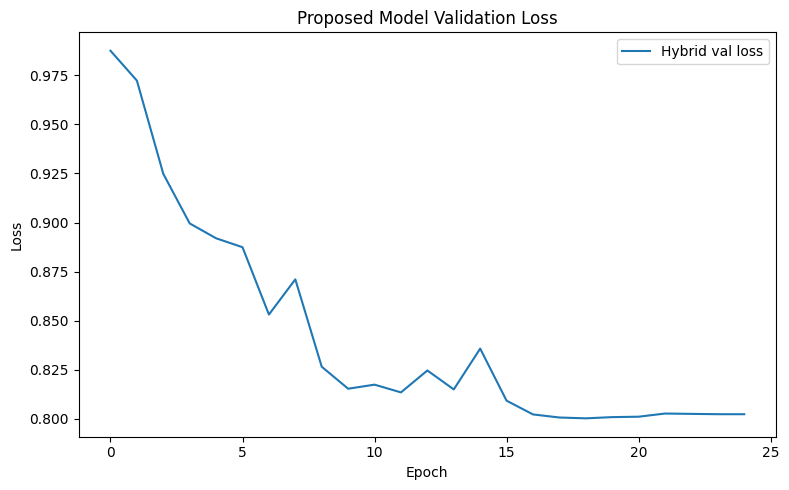

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


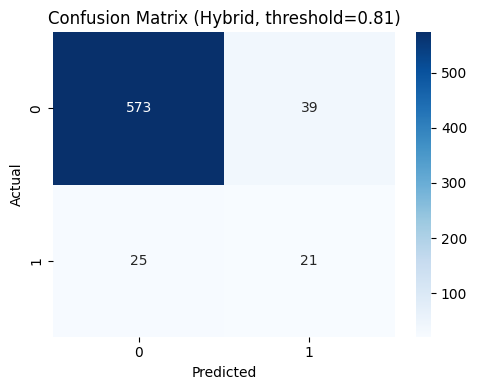

In [22]:
hybrid_probs, hybrid_targets = test_predictions["hybrid"]
hybrid_threshold = selected_thresholds["hybrid"]
hybrid_pred_labels = (hybrid_probs >= hybrid_threshold).astype(int)

plt.figure(figsize=(5, 4))
cm = confusion_matrix(hybrid_targets, hybrid_pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Hybrid, threshold={hybrid_threshold:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300)
plt.show()


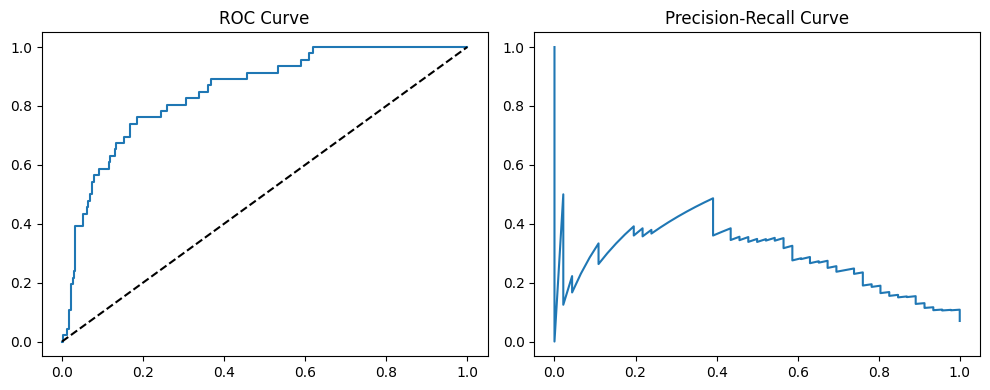

In [23]:
fpr, tpr, _ = roc_curve(hybrid_targets, hybrid_probs)
precision, recall, _ = precision_recall_curve(hybrid_targets, hybrid_probs)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fpr, tpr); axes[0].plot([0, 1], [0, 1], "k--"); axes[0].set_title("ROC Curve")
axes[1].plot(recall, precision); axes[1].set_title("Precision-Recall Curve")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300); plt.show()


### Explainable AI

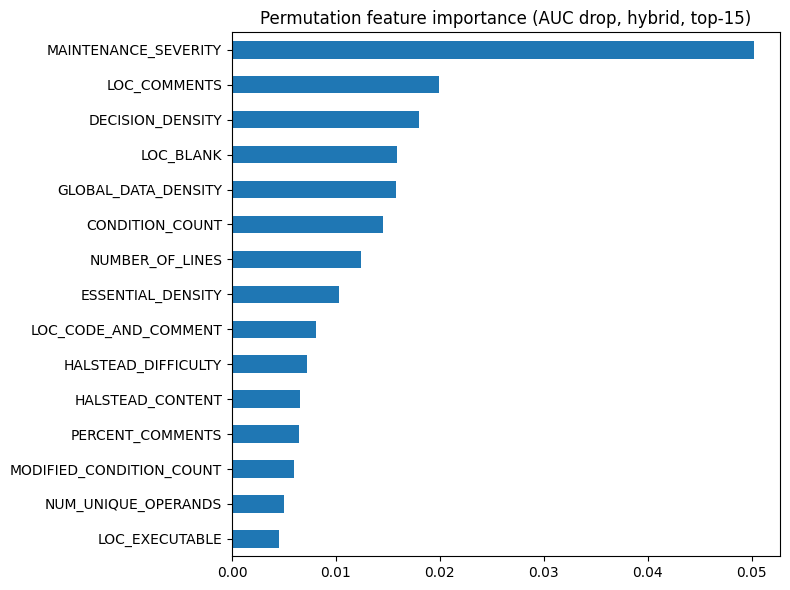

In [24]:
# fig04 - pipeline-level permutation importance (AUC drop, hybrid model).
# When one metric is permuted, k-NN neighborhoods are recomputed so the graph branch is also tested.
from sklearn.metrics import roc_auc_score as _auc

base_score = _auc(hybrid_targets, hybrid_probs) if len(np.unique(hybrid_targets)) > 1 else 0.5
rng = np.random.default_rng(SEED)
importances = {}

hybrid.eval()
for i, col in enumerate(numeric_cols):
    X_perm = test_ds.X.copy()
    X_perm[:, i] = rng.permutation(X_perm[:, i])

    perm_neighbors = query_train_neighbor_features(X_perm)

    with torch.no_grad():
        x_tensor = torch.from_numpy(X_perm).to(DEVICE)
        g_tensor = torch.from_numpy(perm_neighbors).to(DEVICE)
        logits = hybrid(x_tensor, g_tensor).squeeze(-1)
        probs_perm = torch.sigmoid(logits).cpu().numpy()

    score_perm = _auc(hybrid_targets, probs_perm) if len(np.unique(hybrid_targets)) > 1 else 0.5
    importances[col] = base_score - score_perm

imp_series = pd.Series(importances).sort_values().tail(15)
plt.figure(figsize=(8, 6))
imp_series.plot(kind="barh")
plt.title("Permutation feature importance (AUC drop, hybrid, top-15)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=300)
plt.show()


### Error Analysis

False negatives: 25 / 46 defects missed
False positives: 39 / 612 clean modules flagged


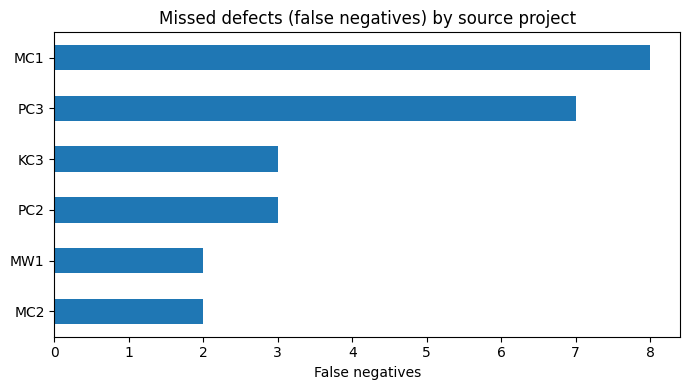

In [25]:
fn_mask = (hybrid_targets == 1) & (hybrid_pred_labels == 0)
fp_mask = (hybrid_targets == 0) & (hybrid_pred_labels == 1)

print(f"False negatives: {fn_mask.sum()} / {int(hybrid_targets.sum())} defects missed")
print(f"False positives: {fp_mask.sum()} / {int((hybrid_targets == 0).sum())} clean modules flagged")

test_projects = test_df["_source_project"].to_numpy()
fn_by_project = pd.Series(test_projects[fn_mask]).value_counts()

plt.figure(figsize=(7, 4))
if len(fn_by_project) > 0:
    fn_by_project.sort_values().plot(kind="barh")
    plt.xlabel("False negatives")
else:
    plt.text(0.5, 0.5, "No false negatives at the selected threshold",
             ha="center", va="center", transform=plt.gca().transAxes)
    plt.xticks([])
    plt.yticks([])

plt.title("Missed defects (false negatives) by source project")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300)
plt.show()


### Computational Efficiency

In [26]:
import time
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.eval()
    xb_b, xb_graph_b, _ = next(iter(test_loader))
    xb_b = xb_b.to(DEVICE)
    xb_graph_b = xb_graph_b.to(DEVICE)
    with torch.no_grad():
        for _ in range(5):
            model(xb_b, xb_graph_b)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(30):
            model(xb_b, xb_graph_b)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = (time.perf_counter() - start) / 30.0
    efficiency[name] = {'total_params': int(total_params), 'trainable_params': int(trainable_params), 'avg_batch_inference_time_sec': float(elapsed), 'throughput_samples_per_sec': float(xb_b.shape[0] / elapsed)}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "total_params": 23105,
    "trainable_params": 23105,
    "avg_batch_inference_time_sec": 0.0012568970999988474,
    "throughput_samples_per_sec": 25459.522501905165
  }
}
